In [91]:
%load_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import torchvision
import omegaconf
from pprint import pprint

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from models.ired import *
from ebm.ired import IREDTrainer

CHECKPOINT = "../../checkpoints/ired.pth"
DEVICE = "cuda"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [92]:
conf = omegaconf.OmegaConf.load("../config/conf.yaml")

energy_model = IREDUnet(conf)
trainer = IREDTrainer(energy_model, conf)

state = torch.load(CHECKPOINT, map_location=DEVICE)
trainer.load_state_dict(state)
trainer.to(DEVICE)
trainer.eval()

print(trainer)
print(f"\nSigma schedule (coarse→fine)")
pprint(trainer.sigmas.tolist())

IREDTrainer(
  (model): IREDUnet(
    (k_embedding): Embedding(50, 64)
    (cond_embedding): Embedding(10, 64)
    (mlp_cond): Sequential(
      (0): Linear(in_features=128, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
    )
    (inc): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down1): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): SiLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): SiLU()
    )
    (down2): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): SiLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): SiLU()
    )
    (bottleneck_

torch.Size([16, 1, 28, 28])


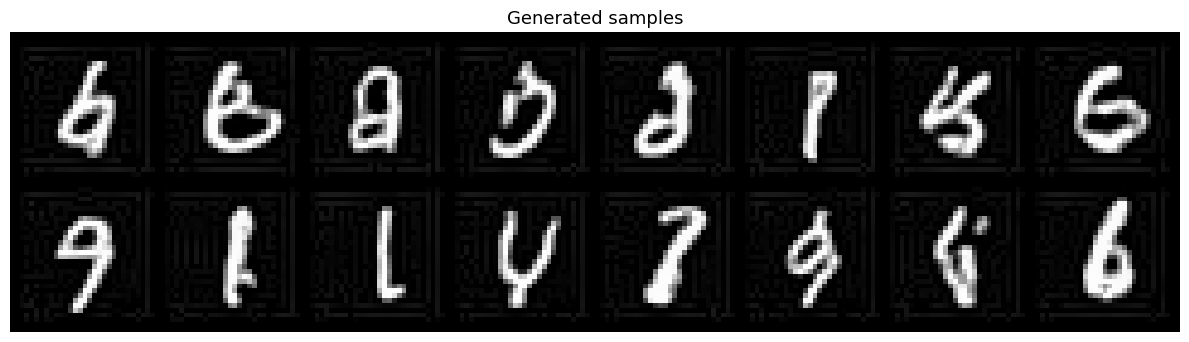

In [98]:
def show_grid(samples, nrow=8, title="Generated samples"):
    grid = torchvision.utils.make_grid(
        samples,
        nrow=nrow,
        normalize=True,  # rescales to [0, 1] across the whole grid
        padding=2,
    )
    np_grid = grid.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(figsize=(min(nrow * 1.5, 16), max(2, len(samples) // nrow * 1.5 + 1)))
    ax.imshow(np_grid, cmap='gray')
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

output = trainer.sample_annealed(
    shape=(16,1,28,28),
    steps_per_landscape=2,
    step_size=0.02,
    condition=torch.full((16,), 1, device="cuda")
)
print(output.shape)

show_grid(output.cpu())